# 🧠 Perceptron from Scratch

## Overview
This notebook contains a foundational deep learning exercise completed during the AI Bootcamp. The objective is to implement the Perceptron algorithm from scratch to better understand the core principles of neural networks.

## Objective
The goal of this exercise is to build and train a single-layer perceptron without relying on high-level deep learning frameworks, providing a deeper understanding of how neural networks learn from data.

## Skills Practiced

- Perceptron Algorithm
- Forward Propagation
- Weight Updates
- Binary Classification
- Neural Network Fundamentals

---
**Tools:** Python, NumPy

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.linear_model

In [2]:
def load_datasets():
    X1, y1 = sklearn.datasets.make_gaussian_quantiles(
      cov=2.0, n_samples=200, n_features=2, n_classes=2, random_state=1)
    X2, y2 = sklearn.datasets.make_gaussian_quantiles(
      mean=(3, 3), cov=1.5, n_samples=300, n_features=2, n_classes=2, random_state=1)

    X = np.concatenate((X1, X2))
    y = np.concatenate((y1, -y2 + 1))

    return X , y

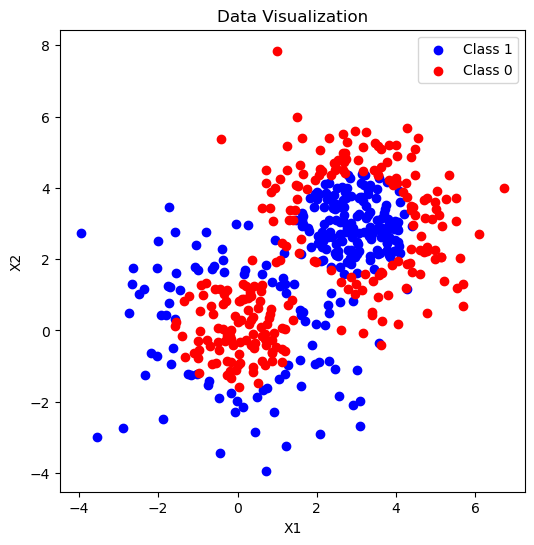

In [3]:
X , y = load_datasets()
plt.figure(figsize=(6,6))
plt.scatter(X[y==1, 0], X[y==1, 1], c='b', label='Class 1')
plt.scatter(X[y==0, 0], X[y==0, 1], c='r', label='Class 0')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Data Visualization')
plt.legend()
plt.show()


In [4]:
from sklearn.linear_model import LogisticRegressionCV
clf = LogisticRegressionCV(cv=5).fit(X, y)


In [5]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_boundary(model, X, y):
    plt.figure(figsize=(10, 5))

    ax = plt.subplot(121)
    disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        cmap=plt.cm.Paired,
        response_method="predict",
        ax=ax,
        xlabel="x",
        ylabel="y")
    
    x_min, x_max = disp.xx0.min(), disp.xx0.max()
    y_min, y_max = disp.xx1.min(), disp.xx1.max()

    plt.axis("tight")

    for i, n, c in zip(range(2), "AB", "br"):
      idx = np.where(y == i)
      plt.scatter(
          X[idx, 0],
          X[idx, 1],
          c=c,
          cmap=plt.cm.Paired,
          s=20,
          edgecolor="k",
          label="Class %s" % n)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend(loc="upper right")
    plt.title("Decision Boundary")

C:\Users\MY-PC\AppData\Local\Temp\ipykernel_15816\2020083047.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0.5, 1.0, 'Logistic Regression')

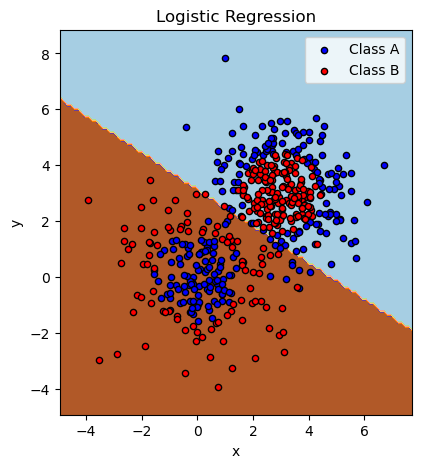

In [6]:
plot_decision_boundary(clf, X, y)
plt.title("Logistic Regression")


In [7]:
n_x = X.shape[1]
n_h = 4
n_y = 1


In [8]:
def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters


In [9]:
parameters = initialize_parameters(n_x, n_h, n_y)

for key, value in parameters.items():
    print(key, value.shape)
    print(value)
    print('-' * 60)


W1 (4, 2)
[[-0.00683852  0.00447976]
 [ 0.01577467 -0.01678759]
 [ 0.00745561  0.00152806]
 [-0.00316999 -0.00404005]]
------------------------------------------------------------
b1 (4, 1)
[[0.]
 [0.]
 [0.]
 [0.]]
------------------------------------------------------------
W2 (1, 4)
[[ 0.00678798  0.00085597  0.01534462 -0.00010295]]
------------------------------------------------------------
b2 (1, 1)
[[0.]]
------------------------------------------------------------


In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [11]:
sigmoid(np.array([[0.]]))


array([[0.5]])

In [12]:
def forward_propagation(X, parameters):
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    Z1 = np.dot(W1, X.T) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}

    return A2, cache


In [13]:
A2, cache = forward_propagation(X, parameters)

for key, value in cache.items():
    print(key, value.shape)


Z1 (4, 500)
A1 (4, 500)
Z2 (1, 500)
A2 (1, 500)


In [14]:
def compute_cost(A2, Y, parameters):
    m = Y.shape[0]
    cost = - np.sum(Y*np.log(A2.T) + (1-Y)*np.log(1-A2.T)) / m
    return cost


In [15]:
print("cost = " + str(compute_cost(A2, y, parameters)))


cost = 346.5735963062278


In [16]:
def backward_propagation(parameters, cache, X, Y):
    m = X.shape[0]
    
    W2 = parameters['W2']
    A1 = cache['A1']
    A2 = cache['A2']

    dZ2 = A2 - Y.reshape(1, m)
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = np.dot(dZ1, X) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}

    return grads


In [17]:
grads = backward_propagation(parameters, cache, X, y)

for key, value in grads.items():
    print(key, value.shape)
    print(value)
    print('-' * 60)


dW1 (4, 2)
[[ 6.10687970e-05  9.21704031e-05]
 [ 7.36003477e-06  1.11208715e-05]
 [ 1.36109669e-04  2.07161605e-04]
 [-9.26136875e-07 -1.39069637e-06]]
------------------------------------------------------------
db1 (4, 1)
[[ 3.73925267e-07]
 [ 3.47313803e-08]
 [ 6.40729581e-07]
 [-4.75014520e-09]]
------------------------------------------------------------
dW2 (1, 4)
[[-9.87661897e-07 -8.43858707e-05  8.80065123e-05 -8.36252739e-05]]
------------------------------------------------------------
db2 (1, 1)
[[5.71608638e-05]]
------------------------------------------------------------


In [18]:
def update_parameters(parameters, grads, learning_rate):
    W1 = parameters['W1'] - learning_rate * grads['dW1']
    b1 = parameters['b1'] - learning_rate * grads['db1']
    W2 = parameters['W2'] - learning_rate * grads['dW2']
    b2 = parameters['b2'] - learning_rate * grads['db2']

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters


In [19]:
parameters = update_parameters(parameters, grads, 1.2)

for key, value in parameters.items():
    print(key, value.shape)
    print(value)
    print('-' * 60)


W1 (4, 2)
[[-0.0069118   0.00436915]
 [ 0.01576584 -0.01680093]
 [ 0.00729228  0.00127946]
 [-0.00316888 -0.00403838]]
------------------------------------------------------------
b1 (4, 1)
[[-4.48710320e-07]
 [-4.16776563e-08]
 [-7.68875497e-07]
 [ 5.70017424e-09]]
------------------------------------------------------------
W2 (1, 4)
[[ 6.78916994e-03  9.57237435e-04  1.52390156e-02 -2.60006620e-06]]
------------------------------------------------------------
b2 (1, 1)
[[-6.85930365e-05]]
------------------------------------------------------------


In [20]:
def nn_model(X, Y, learning_rate, num_iterations = 10000):
    n_x = X.shape[1]
    n_h = 4
    n_y = 1
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y, parameters)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.6f}")
            
    return parameters


In [21]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    predictions = (A2 > 0.5).astype(int)
    return predictions


In [22]:
parameters = nn_model(X, y, learning_rate = 0.1 , num_iterations = 150000)


Cost after iteration 0: 346.573616
Cost after iteration 1000: 346.574217
Cost after iteration 2000: 346.583921
Cost after iteration 3000: 346.592336
Cost after iteration 4000: 346.596733
Cost after iteration 5000: 346.599490
Cost after iteration 6000: 346.601497
Cost after iteration 7000: 346.603083
Cost after iteration 8000: 346.604389
Cost after iteration 9000: 346.605491
Cost after iteration 10000: 346.606439
Cost after iteration 11000: 346.607266
Cost after iteration 12000: 346.607996
Cost after iteration 13000: 346.608648
Cost after iteration 14000: 346.609235
Cost after iteration 15000: 346.609768
Cost after iteration 16000: 346.610255
Cost after iteration 17000: 346.610703
Cost after iteration 18000: 346.611116
Cost after iteration 19000: 346.611500
Cost after iteration 20000: 346.611859
Cost after iteration 21000: 346.612194
Cost after iteration 22000: 346.612510
Cost after iteration 23000: 346.612807
Cost after iteration 24000: 346.613088
Cost after iteration 25000: 346.613355

In [23]:
def plot_decision_boundary_for_nn(model, X, y):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)


Text(0.5, 1.0, 'Decision Boundary for NN')

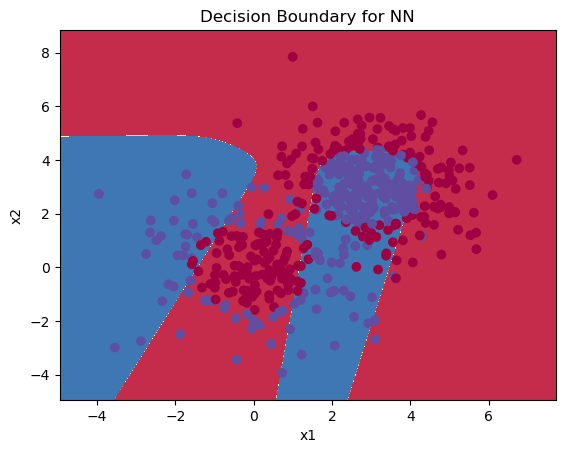

In [24]:
plot_decision_boundary_for_nn(lambda x: predict(parameters, x), X.T, y.T)
plt.title("Decision Boundary for NN")
